In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
filtered = pd.read_csv('bobcat_163_True.csv')
unfiltered = pd.read_csv('bobcat_163_False.csv')
# FILTERING BY PEOPLE WITH SUBJECT ID = 155 - 665 train, 214 valid, 215 test
# Parse comma-separated IDs
filtered['q_ids'] = filtered['sampled_q_ids'].str.split(',')
filtered['subj_ids'] = filtered['sampled_subject_ids'].str.split(',')
unfiltered['q_ids'] = unfiltered['sampled_q_ids'].str.split(',')
unfiltered['subj_ids'] = unfiltered['sampled_subject_ids'].str.split(',')

In [9]:
filtered.head()

,user_id,sampled_q_ids,sampled_subject_ids,student_total_questions,q_ids,subj_ids
0,3652,"49,51,53,56,92,93,212,236,259,265","128,117,148,128,148,148,148,56,148,128",61,"[49, 51, 53, 56, 92, 93, 212, 236, 259, 265]","[128, 117, 148, 128, 148, 148, 148, 56, 148, 128]"
1,2479,"3,45,47,50,83,134,143,171,178,185","155,155,127,154,126,155,155,128,155,154",55,"[3, 45, 47, 50, 83, 134, 143, 171, 178, 185]","[155, 155, 127, 154, 126, 155, 155, 128, 155, ..."
2,100,"6,23,27,37,51,67,76,193,198,221","148,125,175,151,117,61,36,21,148,60",80,"[6, 23, 27, 37, 51, 67, 76, 193, 198, 221]","[148, 125, 175, 151, 117, 61, 36, 21, 148, 60]"
3,983,"2,24,34,40,46,47,49,50,56,69","3,156,156,156,3,156,127,128,154,128,3",156,"[2, 24, 34, 40, 46, 47, 49, 50, 56, 69]","[3, 156, 156, 156, 3, 156, 127, 128, 154, 128, 3]"
4,4540,"2,3,6,11,18,24,29,30,31,34","3,156,155,148,156,156,156,156,21,156,156",251,"[2, 3, 6, 11, 18, 24, 29, 30, 31, 34]","[3, 156, 155, 148, 156, 156, 156, 156, 21, 156..."


In [10]:
unfiltered.head()

,user_id,sampled_q_ids,sampled_subject_ids,student_total_questions,q_ids,subj_ids
0,3652,"830,840,767,6,768,475,563,165,522,304","148,163,148,148,128,148,154,164,148,164",61,"[830, 840, 767, 6, 768, 475, 563, 165, 522, 304]","[148, 163, 148, 148, 128, 148, 154, 164, 148, ..."
1,2479,"736,547,106,83,463,497,520,484,638,45","155,155,128,126,155,128,127,127,154,155",55,"[736, 547, 106, 83, 463, 497, 520, 484, 638, 45]","[155, 155, 128, 126, 155, 128, 127, 127, 154, ..."
2,100,"300,840,377,6,193,563,779,51,368,37","153,163,155,148,21,154,127,117,3,151",80,"[300, 840, 377, 6, 193, 563, 779, 51, 368, 37]","[153, 163, 155, 148, 21, 154, 127, 117, 3, 151]"
3,983,"736,852,502,370,69,83,129,47,768,551","155,156,36,195,3,126,165,127,128,195",156,"[736, 852, 502, 370, 69, 83, 129, 47, 768, 551]","[155, 156, 36, 195, 3, 126, 165, 127, 128, 195]"
4,4540,"736,300,740,898,547,118,170,859,97,463","155,153,36,39,155,114,39,33,39,155",251,"[736, 300, 740, 898, 547, 118, 170, 859, 97, 463]","[155, 153, 36, 39, 155, 114, 39, 33, 39, 155]"


In [3]:
all_subj_filtered = [s for subj_list in filtered['subj_ids'] for s in subj_list]
all_subj_unfiltered = [s for subj_list in unfiltered['subj_ids'] for s in subj_list]

subj_counts_f = pd.Series(all_subj_filtered).value_counts()
subj_counts_u = pd.Series(all_subj_unfiltered).value_counts()

comparison = pd.DataFrame({
    'Filtered': subj_counts_f,
    'Unfiltered': subj_counts_u
}).fillna(0).astype(int)
comparison['Difference'] = comparison['Filtered'] - comparison['Unfiltered']
comparison2 = comparison.sort_values('Difference', ascending=False)
print(comparison.head(20))
print("="*40)
print(comparison2.head(20))

     Filtered  Unfiltered  Difference
114       171         346        -175
117        49         137         -88
125        56          42          14
126        75         201        -126
127       287         304         -17
128       444         221         223
129        12          70         -58
130         2          28         -26
135         0          27         -27
137       272          46         226
146       111         311        -200
148       754         865        -111
151       123           7         116
153       243         567        -324
154       142          23         119
155       718        1068        -350
156      1792         476        1316
163        45         251        -206
164       317         571        -254
165        41         197        -156
     Filtered  Unfiltered  Difference
156      1792         476        1316
189       824          14         810
44        549         118         431
56        326           5         321
202       24

In [4]:
# 2. Per-student overlap
overlaps = []
for _, f_row in filtered.iterrows():
    u_row = unfiltered[unfiltered['user_id'] == f_row['user_id']]
    if not u_row.empty:
        u_row = u_row.iloc[0]
        
        q_f = set(f_row['q_ids'])
        q_u = set(u_row['q_ids'])
        s_f = set(f_row['subj_ids'])
        s_u = set(u_row['subj_ids'])
        
        overlaps.append({
            'user_id': f_row['user_id'],
            'q_overlap': len(q_f & q_u),
            'q_overlap_pct': len(q_f & q_u) / len(q_f) * 100,
            's_overlap': len(s_f & s_u),
            's_overlap_pct': len(s_f & s_u) / len(s_f) * 100
        })

overlap_df = pd.DataFrame(overlaps)

print(f"Average Question Overlap: {overlap_df['q_overlap_pct'].mean():.1f}%")
print(f"Average Subject Overlap: {overlap_df['s_overlap_pct'].mean():.1f}%")
print(f"\nStudents analyzed: {len(overlap_df)}")


Average Question Overlap: 5.4%
Average Subject Overlap: 45.8%

Students analyzed: 983


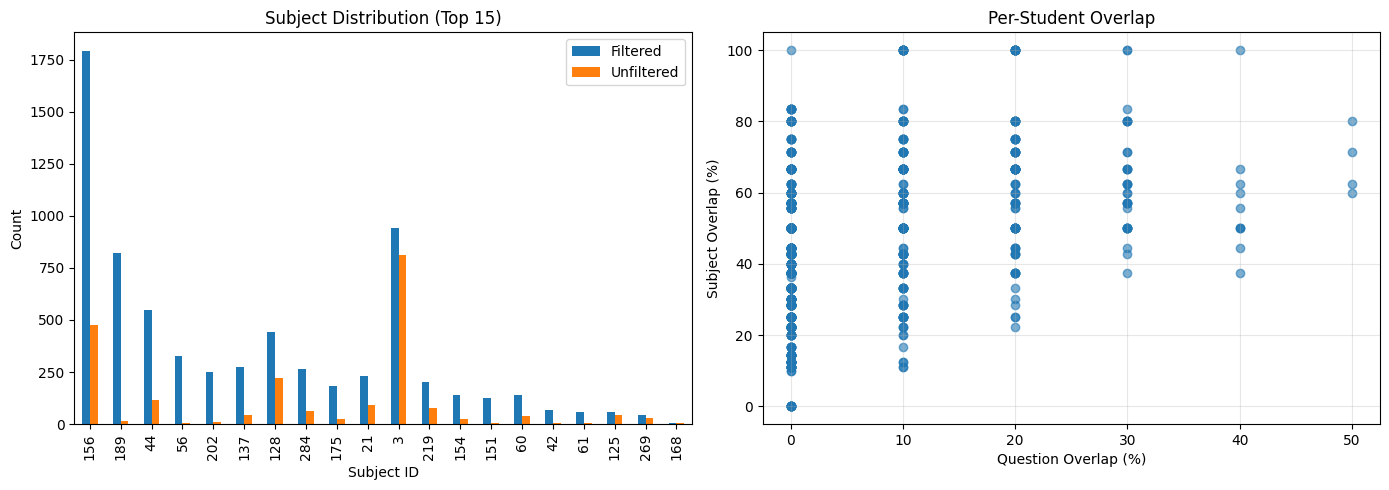

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subject distribution
top_subjects = comparison2.head(20)
top_subjects[['Filtered', 'Unfiltered']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Subject Distribution (Top 15)')
axes[0].set_xlabel('Subject ID')
axes[0].set_ylabel('Count')
axes[0].legend(['Filtered', 'Unfiltered'])

# Overlap scatter
axes[1].scatter(overlap_df['q_overlap_pct'], overlap_df['s_overlap_pct'], alpha=0.6)
axes[1].set_xlabel('Question Overlap (%)')
axes[1].set_ylabel('Subject Overlap (%)')
axes[1].set_title('Per-Student Overlap')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

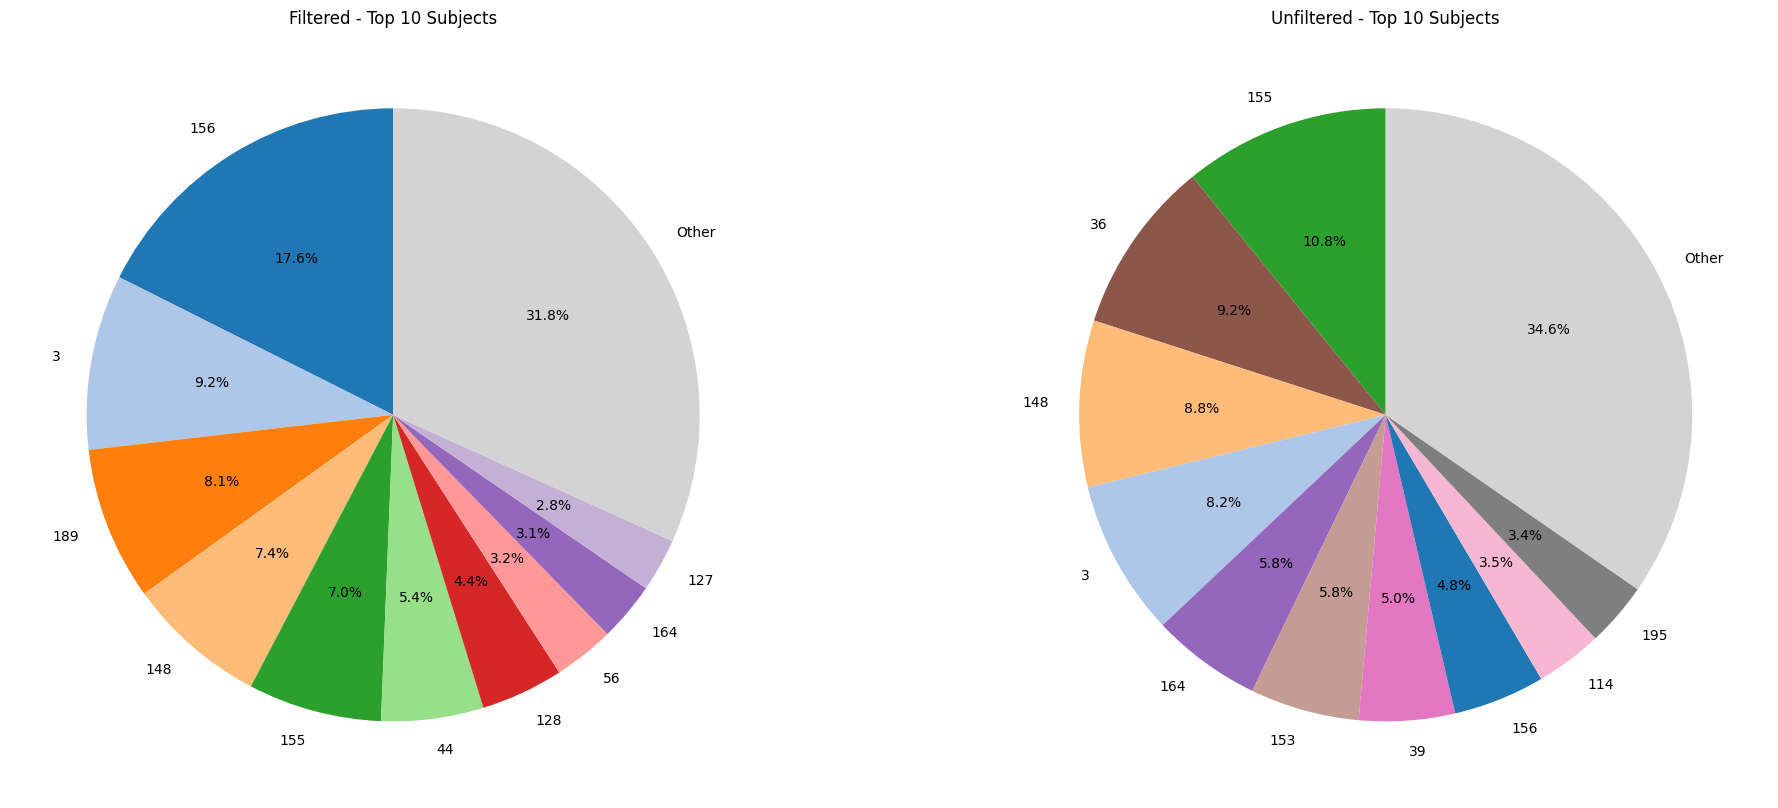

In [6]:
fig = plt.figure(figsize=(20, 16))
top_n = 10

# Get all unique subjects from both datasets and create color map
all_top_subjects = pd.concat([subj_counts_f.head(top_n), subj_counts_u.head(top_n)]).index.unique()
colors = plt.cm.tab20(range(len(all_top_subjects)))
color_map = {subj: colors[i] for i, subj in enumerate(all_top_subjects)}
color_map['Other'] = 'lightgray'

# Filtered pie
ax3 = plt.subplot(2, 2, 3)
top_filtered = subj_counts_f.head(top_n)
other_filtered = subj_counts_f.iloc[top_n:].sum()
pie_filtered = pd.concat([top_filtered, pd.Series({'Other': other_filtered})])
filtered_colors = [color_map.get(subj, 'gray') for subj in pie_filtered.index]
ax3.pie(pie_filtered, labels=pie_filtered.index, autopct='%1.1f%%', startangle=90, colors=filtered_colors)
ax3.set_title(f'Filtered - Top {top_n} Subjects')

# Unfiltered pie
ax4 = plt.subplot(2, 2, 4)
top_unfiltered = subj_counts_u.head(top_n)
other_unfiltered = subj_counts_u.iloc[top_n:].sum()
pie_unfiltered = pd.concat([top_unfiltered, pd.Series({'Other': other_unfiltered})])
unfiltered_colors = [color_map.get(subj, 'gray') for subj in pie_unfiltered.index]
ax4.pie(pie_unfiltered, labels=pie_unfiltered.index, autopct='%1.1f%%', startangle=90, colors=unfiltered_colors)
ax4.set_title(f'Unfiltered - Top {top_n} Subjects')

plt.tight_layout()
plt.show()